In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import chi2_contingency
from scipy.stats import spearmanr
from scipy.stats import pearsonr

In [67]:
df = pd.read_csv(
    "../data/cleaned/final_dataset_with_features.csv"
)

In [68]:
pearson_v1 = pearsonr(
    df["loyalty_score_v1"],
    df["customer_lifetime_value_proxy"]
)

pearson_v2 = pearsonr(
    df["loyalty_score_v2"],
    df["customer_lifetime_value_proxy"]
)

print("Pearson V1:", pearson_v1)
print("Pearson V2:", pearson_v2)

Pearson V1: PearsonRResult(statistic=np.float64(0.4113570512791043), pvalue=np.float64(3.7625571976923133e-159))
Pearson V2: PearsonRResult(statistic=np.float64(0.8148020445182862), pvalue=np.float64(0.0))


In [69]:
spearman_v1 = spearmanr(
    df["loyalty_score_v1"],
    df["customer_lifetime_value_proxy"]
)

spearman_v2 = spearmanr(
    df["loyalty_score_v2"],
    df["customer_lifetime_value_proxy"]
)

print("Spearman V1:", spearman_v1)
print("Spearman V2:", spearman_v2)

Spearman V1: SignificanceResult(statistic=np.float64(0.44557882040271385), pvalue=np.float64(1.3253654206516028e-189))
Spearman V2: SignificanceResult(statistic=np.float64(0.783732251413852), pvalue=np.float64(0.0))


### Lotalty Segments

Group - Definition
- Loyal	: Top 25%
- Growth :	Middle 50%
- At-Risk :	Bottom 25%

Using loyalty_score_v2 because it is stronger commercially

In [70]:
q1 = df["loyalty_score_v2"].quantile(0.25)
q3 = df["loyalty_score_v2"].quantile(0.75)

In [71]:
def loyalty_segment(score):

    if score >= q3:
        return "Loyal"

    elif score <= q1:
        return "At-Risk"

    else:
        return "Growth"

In [72]:
df["loyalty_segment"] = (
    df["loyalty_score_v2"]
    .apply(loyalty_segment)
)

In [73]:
df["loyalty_segment"].value_counts()

loyalty_segment
Growth     1950
Loyal       975
At-Risk     975
Name: count, dtype: int64

In [74]:
contingency_table = pd.crosstab(
    df["loyalty_segment"],
    df["promo_dependency_score"]
)

contingency_table

promo_dependency_score,0.0,1.0
loyalty_segment,,
At-Risk,636,339
Growth,1137,813
Loyal,450,525


### Loyalty Validation Interpretation

`loyalty_score_v2` demonstrates a substantially stronger relationship with estimated customer lifetime value compared to `loyalty_score_v1`.

This suggests:

- `loyalty_score_v2` is more effective for identifying commercially valuable customers
- `loyalty_score_v1` captures broader behavioral engagement patterns independent of spending

The distinction between behavioral loyalty and commercial value was intentionally preserved throughout the analysis.

### Chi-Square Validation Interpretation

The chi-square test evaluates whether loyalty segments differ significantly in promotional dependency behavior.

The extremely small p-value indicates that promotional dependency varies significantly across loyalty segments.

This statistically validates the segmentation framework and confirms that the loyalty segmentation captures meaningful behavioral differences.

In [75]:
chi2, p, dof, expected = chi2_contingency(
    contingency_table
)

print("Chi-Square Statistic:", chi2)
print("P-Value:", p)

Chi-Square Statistic: 75.10592222954524
P-Value: 4.908583788690932e-17


# Customer Segmentation Using K-Means

In [76]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [77]:
features = [
    "customer_lifetime_value_proxy",
    "customer_engagement_score",
    "retention_risk_score",
    "promo_dependency_score",
    "normalized_frequency_score"
]

In [78]:
X = df[features]

In [79]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [80]:
silhouette_scores = []

k_values = range(2, 7)

for k in k_values:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    cluster_labels = kmeans.fit_predict(X_scaled)

    score = silhouette_score(
        X_scaled,
        cluster_labels
    )

    silhouette_scores.append(score)

    print(f"K={k}, Silhouette Score={score:.4f}")

K=2, Silhouette Score=0.3909
K=3, Silhouette Score=0.3644
K=4, Silhouette Score=0.3893
K=5, Silhouette Score=0.3670
K=6, Silhouette Score=0.3533


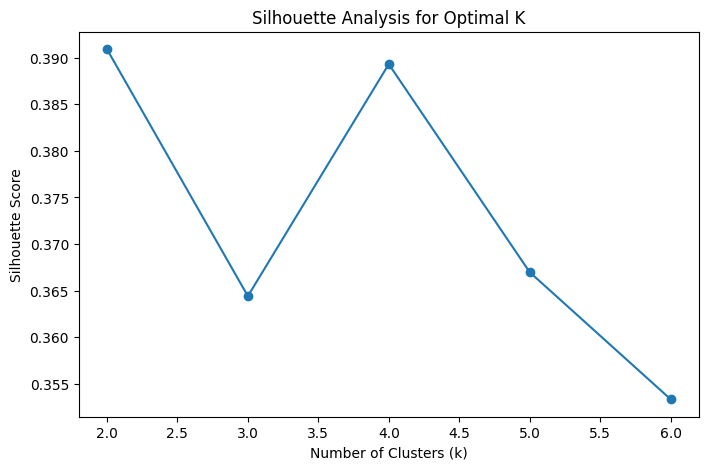

In [81]:
plt.figure(figsize=(8,5))

plt.plot(
    k_values,
    silhouette_scores,
    marker='o'
)

plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Analysis for Optimal K")

plt.show()

In [82]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

df["cluster"] = kmeans.fit_predict(X_scaled)

In [83]:
df["cluster"].value_counts()

cluster
3    1189
0    1034
2     910
1     767
Name: count, dtype: int64

In [84]:
cluster_profile = df.groupby("cluster")[
    features
].mean()

cluster_profile

,customer_lifetime_value_proxy,customer_engagement_score,retention_risk_score,promo_dependency_score,normalized_frequency_score
cluster,,,,,
0,9662.016441,0.516288,0.168714,0.0,0.780303
1,10047.099087,0.731041,0.572164,1.0,0.775967
2,3149.037363,0.442637,0.774945,1.0,0.253846
3,3156.777124,0.273241,0.379563,0.0,0.239417


In [85]:
cluster_profile = df.groupby("cluster")[[
    "customer_lifetime_value_proxy",
    "customer_engagement_score",
    "retention_risk_score",
    "promo_dependency_score",
    "normalized_frequency_score",
    "Purchase Amount (USD)",
    "Previous Purchases"
]].mean()

cluster_profile

,customer_lifetime_value_proxy,customer_engagement_score,retention_risk_score,promo_dependency_score,normalized_frequency_score,Purchase Amount (USD),Previous Purchases
cluster,,,,,,,
0,9662.016441,0.516288,0.168714,0.0,0.780303,61.783366,27.096712
1,10047.099087,0.731041,0.572164,1.0,0.775967,61.563233,28.574967
2,3149.037363,0.442637,0.774945,1.0,0.253846,57.353846,23.356044
3,3156.777124,0.273241,0.379563,0.0,0.239417,58.693019,23.281749


In [86]:
cluster_name_map = {
    0: "Loyal High-Value",
    1: "High-Value Promo Dependent",
    2: "At-Risk Promo Customers",
    3: "Dormant Organic"
}

In [87]:
df["customer_segment"] = (
    df["cluster"]
    .map(cluster_name_map)
)

In [88]:
df["customer_segment"].value_counts()

customer_segment
Dormant Organic               1189
Loyal High-Value              1034
At-Risk Promo Customers        910
High-Value Promo Dependent     767
Name: count, dtype: int64

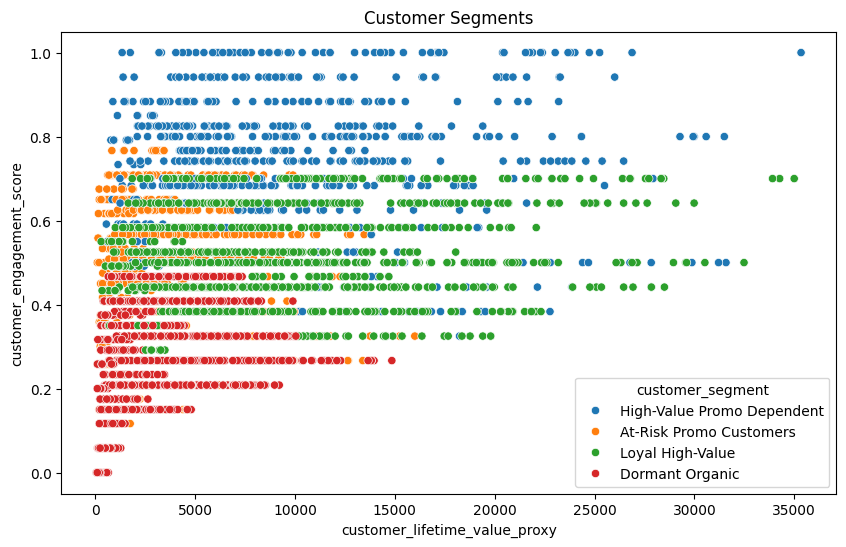

In [89]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x="customer_lifetime_value_proxy",
    y="customer_engagement_score",
    hue="customer_segment"
)

plt.title("Customer Segments")

plt.show()

### Cluster Selection Interpretation

Although K=2 produced the highest silhouette score, K=4 was selected because it provided significantly richer business interpretability with only a minimal reduction in clustering quality.

The four-cluster structure better captures:
- high-value organic customers
- high-value promotion-dependent customers
- at-risk discount-driven customers
- dormant organic customers

This tradeoff prioritizes business usefulness over purely mathematical optimization.

In [90]:
segment_profile = df.groupby(
    "customer_segment"
)[
    [
        "customer_lifetime_value_proxy",
        "customer_engagement_score",
        "retention_risk_score",
        "promo_dependency_score",
        "Purchase Amount (USD)",
        "Previous Purchases",
        "frequency_score",
        "loyalty_score_v1",
        "loyalty_score_v2"
    ]
].mean().round(2)

In [91]:
segment_profile

,customer_lifetime_value_proxy,customer_engagement_score,retention_risk_score,promo_dependency_score,Purchase Amount (USD),Previous Purchases,frequency_score,loyalty_score_v1,loyalty_score_v2
customer_segment,,,,,,,,,
At-Risk Promo Customers,3149.04,0.44,0.77,1.0,57.35,23.36,2.52,0.31,0.24
Dormant Organic,3156.78,0.27,0.38,0.0,58.69,23.28,2.44,0.51,0.21
High-Value Promo Dependent,10047.10,0.73,0.57,1.0,61.56,28.57,5.66,0.55,0.48
Loyal High-Value,9662.02,0.52,0.17,0.0,61.78,27.10,5.68,0.75,0.42


In [92]:
segment_sizes = df[
    "customer_segment"
].value_counts()

In [93]:
segment_profile["customer_count"] = (
    segment_sizes
)

In [94]:
segment_profile

,customer_lifetime_value_proxy,customer_engagement_score,retention_risk_score,promo_dependency_score,Purchase Amount (USD),Previous Purchases,frequency_score,loyalty_score_v1,loyalty_score_v2,customer_count
customer_segment,,,,,,,,,,
At-Risk Promo Customers,3149.04,0.44,0.77,1.0,57.35,23.36,2.52,0.31,0.24,910
Dormant Organic,3156.78,0.27,0.38,0.0,58.69,23.28,2.44,0.51,0.21,1189
High-Value Promo Dependent,10047.10,0.73,0.57,1.0,61.56,28.57,5.66,0.55,0.48,767
Loyal High-Value,9662.02,0.52,0.17,0.0,61.78,27.10,5.68,0.75,0.42,1034


In [95]:
top_category = (
    df.groupby("customer_segment")["Category"]
    .agg(lambda x: x.value_counts().index[0])
)

In [96]:
segment_profile["top_category"] = (
    top_category
)

In [97]:
top_payment_method = (
    df.groupby("customer_segment")["Payment Method"]
    .agg(lambda x: x.value_counts().index[0])
)

In [98]:
segment_profile["preferred_payment_method"] = (
    top_payment_method
)

In [99]:
top_location = (
    df.groupby("customer_segment")["Location"]
    .agg(lambda x: x.value_counts().index[0])
)

In [100]:
segment_profile["top_location"] = (
    top_location
)

In [101]:
df["promo_revenue"] = np.where(
    df["promo_dependency_score"] == 1,
    df["Purchase Amount (USD)"],
    0
    )


In [102]:
promo_analysis = df.groupby(
    "customer_segment"
).agg(
    total_revenue = (
        "Purchase Amount (USD)",
        "sum"
    ),
    promo_revenue = (
        "promo_revenue",
        "sum"
    )
)

In [103]:
promo_analysis["promo_revenue_percent"] = (
    promo_analysis["promo_revenue"] /
    promo_analysis["total_revenue"]
) * 100

In [104]:
promo_analysis = promo_analysis.round(2)

In [105]:
promo_analysis

,total_revenue,promo_revenue,promo_revenue_percent
customer_segment,,,
At-Risk Promo Customers,52192,52192,100.0
Dormant Organic,69786,0,0.0
High-Value Promo Dependent,47219,47219,100.0
Loyal High-Value,63884,0,0.0


In [106]:
segment_profile = segment_profile.merge(
    promo_analysis[
        [
            "promo_revenue_percent"
        ]
    ],
    left_index=True,
    right_index=True
)

In [107]:
segment_profile

,customer_lifetime_value_proxy,customer_engagement_score,retention_risk_score,promo_dependency_score,Purchase Amount (USD),Previous Purchases,frequency_score,loyalty_score_v1,loyalty_score_v2,customer_count,top_category,preferred_payment_method,top_location,promo_revenue_percent
customer_segment,,,,,,,,,,,,,,
At-Risk Promo Customers,3149.04,0.44,0.77,1.0,57.35,23.36,2.52,0.31,0.24,910,clothing,debit card,minnesota,100.0
Dormant Organic,3156.78,0.27,0.38,0.0,58.69,23.28,2.44,0.51,0.21,1189,clothing,credit card,montana,0.0
High-Value Promo Dependent,10047.10,0.73,0.57,1.0,61.56,28.57,5.66,0.55,0.48,767,clothing,venmo,north carolina,100.0
Loyal High-Value,9662.02,0.52,0.17,0.0,61.78,27.10,5.68,0.75,0.42,1034,clothing,cash,tennessee,0.0


In [108]:
segment_profile.to_csv("../data/cleaned/segment_profiles.csv")

In [109]:
df.to_csv("../data/cleaned/final_segmented_dataset.csv", index=False)

# Segment Interpretation

The customer segmentation analysis identified four distinct behavioral and commercial customer groups.

The segmentation reveals that:
- customer value and customer loyalty are not always equivalent
- promotional dependency strongly influences retention quality
- organically loyal customers exhibit significantly lower retention risk
- some of the highest-value customers remain highly dependent on discounts

These findings directly support the project's central business objective of evaluating whether the company is building sustainable loyalty or promotion-driven revenue dependency.

# Segment Insight Mining

In [110]:
segment_profile = segment_profile[
    [
        "customer_count",
        "customer_lifetime_value_proxy",
        "customer_engagement_score",
        "retention_risk_score",
        "promo_dependency_score",
        "promo_revenue_percent",
        "Purchase Amount (USD)",
        "Previous Purchases",
        "frequency_score",
        "loyalty_score_v1",
        "loyalty_score_v2"
    ]
]

In [111]:
segment_profile

,customer_count,customer_lifetime_value_proxy,customer_engagement_score,retention_risk_score,promo_dependency_score,promo_revenue_percent,Purchase Amount (USD),Previous Purchases,frequency_score,loyalty_score_v1,loyalty_score_v2
customer_segment,,,,,,,,,,,
At-Risk Promo Customers,910,3149.04,0.44,0.77,1.0,100.0,57.35,23.36,2.52,0.31,0.24
Dormant Organic,1189,3156.78,0.27,0.38,0.0,0.0,58.69,23.28,2.44,0.51,0.21
High-Value Promo Dependent,767,10047.10,0.73,0.57,1.0,100.0,61.56,28.57,5.66,0.55,0.48
Loyal High-Value,1034,9662.02,0.52,0.17,0.0,0.0,61.78,27.10,5.68,0.75,0.42


In [112]:
segment_revenue = df.groupby(
    "customer_segment"
)["Purchase Amount (USD)"].sum()

In [113]:
segment_revenue_percent = (
    segment_revenue /
    segment_revenue.sum()
) * 100

In [114]:
segment_profile["revenue_percent"] = (
    segment_revenue_percent.round(2)
)

C:\Users\dines\AppData\Local\Temp\ipykernel_24428\880298837.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  segment_profile["revenue_percent"] = (


In [115]:
segment_profile["revenue_per_customer"] = (
    df.groupby("customer_segment")[
        "Purchase Amount (USD)"
    ].sum()
    /
    segment_profile["customer_count"]
).round(2)

C:\Users\dines\AppData\Local\Temp\ipykernel_24428\2378327350.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  segment_profile["revenue_per_customer"] = (


In [116]:
segment_profile = segment_profile[
    [
        "customer_count",
        "revenue_percent",
        "revenue_per_customer",
        "customer_lifetime_value_proxy",
        "customer_engagement_score",
        "retention_risk_score",
        "promo_dependency_score",
        "promo_revenue_percent",
        "frequency_score",
        "loyalty_score_v1",
        "loyalty_score_v2"
    ]
]

In [117]:
segment_profile

,customer_count,revenue_percent,revenue_per_customer,customer_lifetime_value_proxy,customer_engagement_score,retention_risk_score,promo_dependency_score,promo_revenue_percent,frequency_score,loyalty_score_v1,loyalty_score_v2
customer_segment,,,,,,,,,,,
At-Risk Promo Customers,910,22.39,57.35,3149.04,0.44,0.77,1.0,100.0,2.52,0.31,0.24
Dormant Organic,1189,29.94,58.69,3156.78,0.27,0.38,0.0,0.0,2.44,0.51,0.21
High-Value Promo Dependent,767,20.26,61.56,10047.10,0.73,0.57,1.0,100.0,5.66,0.55,0.48
Loyal High-Value,1034,27.41,61.78,9662.02,0.52,0.17,0.0,0.0,5.68,0.75,0.42


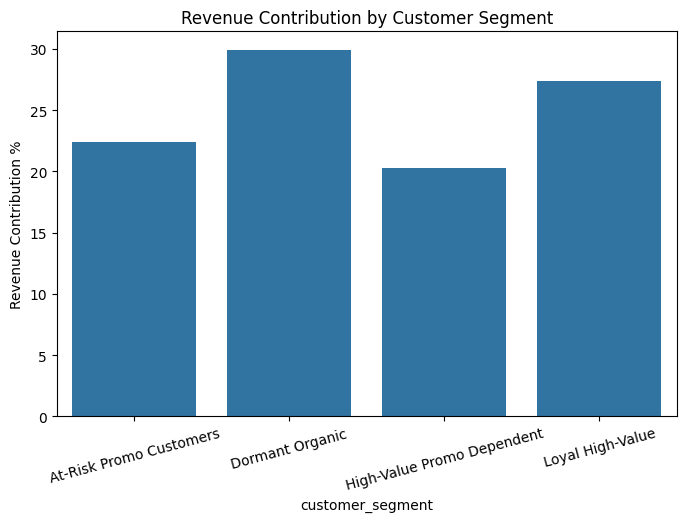

In [118]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=segment_revenue_percent.index,
    y=segment_revenue_percent.values
)

plt.xticks(rotation=15)

plt.ylabel("Revenue Contribution %")
plt.title("Revenue Contribution by Customer Segment")

plt.show()

In [119]:
segment_profile.to_csv(
    "../data/cleaned/segment_profiles.csv"
)

In [120]:
df.to_csv(
    "../data/cleaned/final_segmented_dataset.csv",
    index=False
)

# Strategic Conclusions

1. The business contains two fundamentally different high-value customer groups:
   - organically loyal high-value customers
   - promotion-dependent high-value customers

2. A significant portion of commercially valuable customers remain heavily reliant on promotions, creating long-term margin risk.

3. Customer lifetime value appears to be driven more strongly by:
   - purchase frequency
   - engagement quality
   - retention stability

rather than by single-purchase spending differences.

4. Organic customers demonstrate lower retention risk even at moderate spending levels, indicating healthier long-term customer relationships.

5. The company should gradually transition from blanket discounting toward engagement-driven retention strategies.